#EDA

---



In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
file_path = '/content/drive/MyDrive/SKRIPSI MANTAP/data sosmed/.Process/Merge data/tt_comments.csv'

df = pd.read_csv(file_path)

In [4]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20356 entries, 0 to 20355
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   komen_tt  19214 non-null  object
dtypes: object(1)
memory usage: 159.2+ KB


(20356, 1)

In [5]:
df.head()

,komen_tt
0,woilah temen gw berenang disitu😹😹
1,uya kuya kapan🗿
2,"""woy ini mahal anj"" 😭😭"
3,"Jangan lupa Eko Patrio, Uya Kuya, Nafa Ubach,"
4,Reaksi Syahroni pulang kaget jadi gelandang


##Analisis Missing Values

In [6]:
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    'Jumlah Missing': missing.values,
    'Persentase (%)': (missing.values / len(df)) * 100
})

print(missing_df)

   Jumlah Missing  Persentase (%)
0            1142         5.61014


##Analisis Duplicate Data

In [7]:
duplicate_count = df['komen_tt'].duplicated().sum()

print(f"Jumlah data duplikat: {duplicate_count}")


duplicates = df[df.duplicated()]
print(duplicates[['komen_tt']])

Jumlah data duplikat: 3655
                                             komen_tt
61     Uya kuya. Eko sm nafa urbach ketar ketir pasti
128                                            mantap
304                           barang² mahal semua jir
463                                               NaN
473                          dari rakyat untuk rakyat
...                                               ...
20347                                             NaN
20348                                             NaN
20349                                             NaN
20351                                             😳😳😳
20355                                             NaN

[3655 rows x 1 columns]


##Analisis Noise

In [8]:
# Pastikan data string
df.columns = df.columns.str.strip()

print(df.columns)

Index(['komen_tt'], dtype='object')


Deteksi URL

In [9]:
import re

url_pattern = r'http\S+|www\S+'

df['contains_url'] = df['komen_tt'].apply(
    lambda x: bool(re.search(url_pattern, str(x)))
)

print(df['contains_url'].value_counts())

print(df[df['contains_url']]['komen_tt'].head())

contains_url
False    20348
True         8
Name: count, dtype: int64
2551                                               waowww😎
4622     @khaiz:eh jirr sekarang kan dpr ahmad sahroni ...
5224                       Porsche, ford,tesla??🤯 wowwwww.
12906                 https://bahasteknologi.com/WbBXIb2Hn
13971    hadeuwwwwwww jd sesih liat kaya gini.....😭😭😭😭 ...
Name: komen_tt, dtype: object


Deteksi Hashtag

In [10]:
hashtag_pattern = r'#\w+'

df['contains_hashtag'] = df['komen_tt'].apply(
    lambda x: bool(re.search(hashtag_pattern, str(x)))
)

print(df['contains_hashtag'].value_counts())

print(df[df['contains_hashtag']]['komen_tt'])

contains_hashtag
False    20337
True        19
Name: count, dtype: int64
2201            Ya allah Kenapa sampek gini😭#ripindonesia🥀
4494     Terkejut bila negara jiran ni sampai rumah men...
5389     semoga dengan adanya kejadian ini, bisa menjad...
5954                                        #ultramanpanik
6683     dpr menolak RUU perampasan aset,tapi massa sud...
6744     jangan demo dimalam hari karena ada penembakan...
6968                        #PerampasanAsetversiRakyat 🔥🔥🔥
7012     dpr menolak RUU perampasan aset,tapi massa sud...
7211      ramaikan hastag\n#bubarkandpr\n#waktunyarevolusi
9353     aku kok ngakak ya lihat org2 pada heboh sendir...
10051    Demo buat tolak DPR, atau demo karena ga kebag...
10424                              #SAHKAN PERAMPASAN ASET
11737                                             #savedpr
12047     6175#31.08#FebyN@𝐒𝐎𝐋𝐎𝟑𝟑𝟑_ ✨The Nice One Champ,✨✨
14273                                     #rumahsrimulyani
15289    DARI RAKYAT ,DIAMBIL RAKYAT.....m

Deteksi Mention

In [11]:
mention_pattern = r'@\w+'

df['contains_mention'] = df['komen_tt'].apply(
    lambda x: bool(re.search(mention_pattern, str(x)))
    if pd.notnull(x) else False
)

print(df['contains_mention'].value_counts())

df[df['contains_mention']]

contains_mention
False    20245
True       111
Name: count, dtype: int64


,komen_tt,contains_url,contains_hashtag,contains_mention
243,@Sani Nurrahmayanti: nah gini aja jangan pasil...,False,False,True
540,@noviasihh,False,False,True
693,"@offa.:nah gini maksudnya,bukan fasilitas umum 😭",False,False,True
718,@alisya,False,False,True
778,@Bella.f ꈍᴗꈍ,False,False,True
...,...,...,...,...
19799,"@R@SYD:intinya Allah maha tau dan maha adil,ke...",False,False,True
19960,"Yg Jadi Pertanyaan,Apa Semua Kerugian Mbak Yu ...",False,False,True
20111,@Dani Jr.,False,False,True
20121,"@𝙱𝚕𝚊𝚌𝚔 𝙰𝚗𝚐𝚎𝚕 ':kalo ada yg menyalahkan ""penjar...",False,False,True


Deteksi Emoji

In [12]:
emoji_pattern = re.compile(
    "["
    u"\U0001F600-\U0001F64F"  # emoticon
    u"\U0001F300-\U0001F5FF"  # simbol & pictograph
    u"\U0001F680-\U0001F6FF"  # transport
    u"\U0001F1E0-\U0001F1FF"  # flags
    "]+",
    flags=re.UNICODE
)

df['contains_emoji'] = df['komen_tt'].apply(
    lambda x: bool(emoji_pattern.search(str(x)))
)

print(df['contains_emoji'].value_counts())

print(df[df['contains_emoji']]['komen_tt'])

contains_emoji
False    14019
True      6337
Name: count, dtype: int64
0                        woilah temen gw berenang disitu😹😹
1                                          uya kuya kapan🗿
2                                   "woy ini mahal anj" 😭😭
8             plis bgt jgn dibakar krna banyan rmh warga😭😭
16                     uya kuya keringet dingin nih pasti😹
                               ...                        
20336    berani2nya kalian njarah rumah ibu ini????? ap...
20337      sebelum dijarah duluan dikeluarin dulu mungkin😭
20343    Hartanya hampir 100T gak ngaruh 🗿 , itu pun cu...
20344                                                  😁😁😁
20351                                                  😳😳😳
Name: komen_tt, Length: 6337, dtype: object


Deteksi Simbol Berlebih

In [13]:
symbol_pattern = r'[^\w\s]'

df['contains_symbol'] = df['komen_tt'].apply(
    lambda x: bool(re.search(symbol_pattern, str(x)))
)

print(df['contains_symbol'].value_counts())

print(df[df['contains_symbol']]['komen_tt'].head())

contains_symbol
True     13499
False     6857
Name: count, dtype: int64
0                woilah temen gw berenang disitu😹😹
1                                  uya kuya kapan🗿
2                           "woy ini mahal anj" 😭😭
3    Jangan lupa Eko Patrio, Uya Kuya, Nafa Ubach,
8     plis bgt jgn dibakar krna banyan rmh warga😭😭
Name: komen_tt, dtype: object


Deteksi Karakter Berulang
*   baguusssss
*   mantapppp



In [14]:
repeat_pattern = r'(.)\1{4,}'

df['contains_repeated_char'] = df['komen_tt'].apply(
    lambda x: bool(re.search(repeat_pattern, str(x).lower()))
)

print(df['contains_repeated_char'].value_counts())

print(df[df['contains_repeated_char']]['komen_tt'].head())


contains_repeated_char
False    19664
True       692
Name: count, dtype: int64
19           UDAH DEH KALI INI GW SETUJU BANGETTTTT!! 😭🔥
48     lucu banget lagi pas ironmen nya di bawa "woy ...
111                    keren bgtt jiirrr 😭😭😭😭😭 ga expect
141                             naaaaaah ini baru mantap
143                                        NAHH GITUUUUU
Name: komen_tt, dtype: object


Deteksi Teks Irrelevant
*   terlalu pendek
*   hanya angka/simbol



In [15]:
def irrelevant_text(text):

    text = str(text).strip()

    # terlalu pendek
    if len(text) < 3:
        return True

    # hanya angka/simbol
    if re.fullmatch(r'[\W\d_]+', text):
        return True

    return False

df['irrelevant_text'] = df['komen_tt'].apply(irrelevant_text)

print(df['irrelevant_text'].value_counts())

print(df[df['irrelevant_text']]['komen_tt'])

irrelevant_text
False    18036
True      2320
Name: count, dtype: int64
24          😭
797        @z
822       😭😭😭
828      😭🤣🤣🤣
935        @n
         ... 
20332    😡😡😡😡
20333     😂😂😂
20342     🥰🥰🥰
20344     😁😁😁
20351     😳😳😳
Name: komen_tt, Length: 2320, dtype: object


Ringkasan Noise


===== RINGKASAN NOISE =====
          Jenis Noise  Jumlah
0          URL/Tautan       8
1             Hashtag      19
2             Mention     111
3   Karakter Berulang     692
4  Teks Tidak Relevan    2320


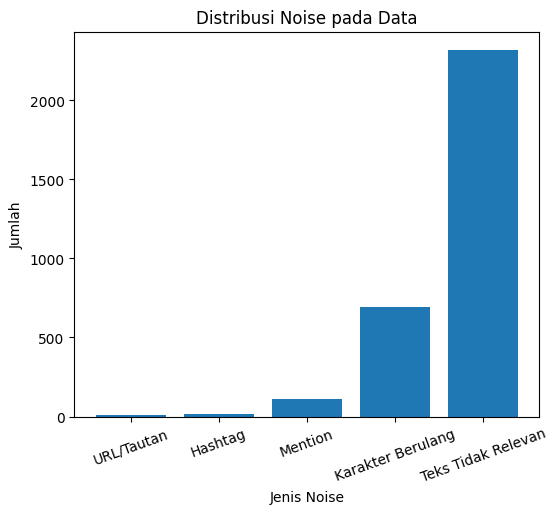

In [16]:
noise_summary = {
    'URL/Tautan': df['contains_url'].sum(),
    'Hashtag': df['contains_hashtag'].sum(),
    'Mention': df['contains_mention'].sum(),
    #'Emoji': df['contains_emoji'].sum(),
    #'Simbol': df['contains_symbol'].sum(),
    'Karakter Berulang': df['contains_repeated_char'].sum(),
    'Teks Tidak Relevan': df['irrelevant_text'].sum()
}

noise_df = pd.DataFrame(
    noise_summary.items(),
    columns=['Jenis Noise', 'Jumlah']
)

print("\n===== RINGKASAN NOISE =====")
print(noise_df)

# Visualisasi Noise
plt.figure(figsize=(6,5))
plt.bar(noise_df['Jenis Noise'], noise_df['Jumlah'])
plt.title('Distribusi Noise pada Data')
plt.xlabel('Jenis Noise')
plt.ylabel('Jumlah')
plt.xticks(rotation=20)
plt.show()

#PREPROCESSING

---



In [17]:
#copy dataset, agar data asli tidak berubah
clean_df = df.copy()

##Case Folding

In [18]:
clean_df['clean_text'] = clean_df['komen_tt'].str.lower()
print(clean_df[['clean_text']].head())

                                      clean_text
0              woilah temen gw berenang disitu😹😹
1                                uya kuya kapan🗿
2                         "woy ini mahal anj" 😭😭
3  jangan lupa eko patrio, uya kuya, nafa ubach,
4    reaksi syahroni pulang kaget jadi gelandang


##Noise Removal

In [19]:
import re

def clean_noise(text):

    text = str(text)

    #hapus url
    text = re.sub(r'http\S+|www\S+', '', text)

    #hapus hashtag
    text = re.sub(r'#', '', text)

    #hapus mention
    text = re.sub(r'@+w', '', text)

    #hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()

    return text

clean_df['clean_text'] = clean_df['clean_text'].apply(clean_noise)

##Normalisasi

Ubah Karakter Berulang

In [20]:
def normalize_repeated_char(word):

    word = re.sub(r'(.)\1{2,}', r'\1', word)

    return word


def normalize_text(text):

    words = text.split()

    normalized_words = [
        normalize_repeated_char(word)
        for word in words
    ]

    return ' '.join(normalized_words)

clean_df['clean_text'] = clean_df['clean_text'].apply(normalize_text)
print(clean_df[['clean_text']].head())

                                      clean_text
0              woilah temen gw berenang disitu😹😹
1                                uya kuya kapan🗿
2                         "woy ini mahal anj" 😭😭
3  jangan lupa eko patrio, uya kuya, nafa ubach,
4    reaksi syahroni pulang kaget jadi gelandang


##Cleaning Data

Hapus Missing Value

In [21]:
clean_df = clean_df.dropna(subset=['clean_text'])

print("Jumlah data setelah hapus missing value:")
print(len(clean_df))

Jumlah data setelah hapus missing value:
20356


Hapus Duplikat Data

In [22]:
clean_df = clean_df.drop_duplicates(subset=['clean_text'])

print("\nJumlah data setelah hapus duplikat:")
print(len(clean_df))


Jumlah data setelah hapus duplikat:
16281


Hapus Teks tidak Relevan

In [23]:
def irrelevant_text(text):

    text = text.strip()

    # terlalu pendek
    if len(text) < 3:
        return True

    # hanya simbol/angka
    if re.fullmatch(r'[\W\d_]+', text):
        return True

    return False

clean_df = clean_df[
    ~clean_df['clean_text'].apply(irrelevant_text)
]

print(len(clean_df))

16035


#HASIL

In [24]:
print("\n===== HASIL PREPROCESSING =====")

print(clean_df[['komen_tt', 'clean_text']].head(10))

print("\nJumlah data akhir:")
print(len(clean_df))


===== HASIL PREPROCESSING =====
                                           komen_tt  \
0                 woilah temen gw berenang disitu😹😹   
1                                   uya kuya kapan🗿   
2                            "woy ini mahal anj" 😭😭   
3     Jangan lupa Eko Patrio, Uya Kuya, Nafa Ubach,   
4       Reaksi Syahroni pulang kaget jadi gelandang   
5  yg ambil ironman KEREN ANJIR ITU MAHAL BANGETTTT   
6                                           lumayan   
7                           barang² mahal semua jir   
8      plis bgt jgn dibakar krna banyan rmh warga😭😭   
9                  Tapi rumah dia banyak deh keknya   

                                      clean_text  
0              woilah temen gw berenang disitu😹😹  
1                                uya kuya kapan🗿  
2                         "woy ini mahal anj" 😭😭  
3  jangan lupa eko patrio, uya kuya, nafa ubach,  
4    reaksi syahroni pulang kaget jadi gelandang  
5  yg ambil ironman keren anjir itu mahal banget  
6   

#SIMPAN HASIL

In [32]:
import os

final_df = clean_df[['clean_text']].copy()

# ubah nama kolom
final_df.columns = ['tt_clean']

In [33]:
folder_path = '/content/drive/MyDrive/SKRIPSI MANTAP/data sosmed/.Process/Clean data'

os.makedirs(folder_path, exist_ok=True)

Simpan ke gdrive

In [27]:
output_path = f'{folder_path}/tt_clean.csv'

final_df.to_csv(output_path, index=False)

print("File berhasil disimpan di:")
print(output_path)

File berhasil disimpan di:
/content/drive/MyDrive/SKRIPSI MANTAP/data sosmed/Clean data/tt_clean.csv


Download

In [28]:
from google.colab import files

files.download(output_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#DISTRIBUSI JUMLAH KATA TIAP KOMENTAR

---



In [29]:
# ======================================
# Distribusi Panjang Komentar
# ======================================

# Hitung jumlah kata pada setiap komentar
clean_df['word_count'] = clean_df['clean_text'].apply(
    lambda x: len(str(x).split())
)

# Hitung jumlah komentar pada setiap rentang
less_50 = (clean_df['word_count'] < 50).sum()
between_50_99 = ((clean_df['word_count'] >= 50) & (clean_df['word_count'] < 100)).sum()
between_100_199 = ((clean_df['word_count'] >= 100) & (clean_df['word_count'] < 200)).sum()
more_equal_200 = (clean_df['word_count'] >= 200).sum()

total = len(clean_df)

print("Distribusi Panjang Komentar")
print("="*40)
print(f"< 50 kata      : {less_50} komentar ({less_50/total*100:.2f}%)")
print(f"50-99 kata     : {between_50_99} komentar ({between_50_99/total*100:.2f}%)")
print(f"100-199 kata   : {between_100_199} komentar ({between_100_199/total*100:.2f}%)")
print(f"≥ 200 kata     : {more_equal_200} komentar ({more_equal_200/total*100:.2f}%)")

Distribusi Panjang Komentar
< 50 kata      : 15904 komentar (99.18%)
50-99 kata     : 115 komentar (0.72%)
100-199 kata   : 16 komentar (0.10%)
≥ 200 kata     : 0 komentar (0.00%)
